##

## 1. Business Understanding
### Problem Statement

### Home Credit Default Risk Prediction

#### Business Problem

Financial institutions face significant losses when customers fail to repay loans.

The objective of this project is to build a machine learning model that predicts whether a customer is likely to default on a loan using their application information, credit history, previous loans, and repayment behavior.

The model will help financial institutions:

- Reduce loan default risk
- Improve loan approval decisions
- Identify high-risk customers
- Support data-driven lending strategies

## 2. Import Libraries

In [13]:
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Styling
sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 3. Load Datasets

In [14]:
application = pd.read_csv("/home/surendran-g/Documents/home-credit-default-risk-prediction/data/raw/application_train.csv")

bureau = pd.read_csv("/home/surendran-g/Documents/home-credit-default-risk-prediction/data/raw/bureau.csv")

bureau_balance = pd.read_csv("/home/surendran-g/Documents/home-credit-default-risk-prediction/data/raw/bureau_balance.csv")

previous_application = pd.read_csv("/home/surendran-g/Documents/home-credit-default-risk-prediction/data/raw/previous_application.csv")

installments = pd.read_csv("/home/surendran-g/Documents/home-credit-default-risk-prediction/data/raw/installments_payments.csv")

pos_cash = pd.read_csv("/home/surendran-g/Documents/home-credit-default-risk-prediction/data/raw/POS_CASH_balance.csv")

credit_card = pd.read_csv("/home/surendran-g/Documents/home-credit-default-risk-prediction/data/raw/credit_card_balance.csv")

## 4. Dataset Inventory

In [15]:
datasets = {
    "application_train": application,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_application,
    "installments": installments,
    "pos_cash": pos_cash,
    "credit_card": credit_card
}

summary = []

for name, df in datasets.items():
    summary.append([
        name,
        df.shape[0],
        df.shape[1]
    ])

summary_df = pd.DataFrame(
    summary,
    columns=["Dataset", "Rows", "Columns"]
)

summary_df

,Dataset,Rows,Columns
0,application_train,307511,122
1,bureau,1716428,17
2,bureau_balance,27299925,3
3,previous_application,1670214,37
4,installments,13605401,8
5,pos_cash,10001358,8
6,credit_card,3840312,23


## 5. Data Relationship Mapping

```text
application_train (Main Table)
        |
        | SK_ID_CURR
        |
        +------ bureau
        |
        +------ previous_application
        |
        +------ installments_payments
        |
        +------ POS_CASH_balance
        |
        +------ credit_card_balance

bureau
        |
        | SK_ID_BUREAU
        |
        +------ bureau_balance


In [23]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


application_train
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'CO

```mermaid
graph TD
    A[application_train] -->|SK_ID_CURR| B[bureau]
    A -->|SK_ID_CURR| C[previous_application]
    A -->|SK_ID_CURR| D[installments_payments]
    A -->|SK_ID_CURR| E[POS_CASH_balance]
    A -->|SK_ID_CURR| F[credit_card_balance]
    
    B -->|SK_ID_BUREAU| G[bureau_balance]

## 6. Initial Data Audit

In [16]:
def data_audit(df):
    audit = pd.DataFrame({
        'Column': df.columns,
        'Dtype': df.dtypes.values,
        'Missing': df.isnull().sum().values,
        'Missing %': np.round(df.isnull().mean().values * 100, 2),
        'Unique Values': df.nunique().values
    })

    return audit

In [17]:
data_audit(application)

,Column,Dtype,Missing,Missing %,Unique Values
0,SK_ID_CURR,int64,0,0.0,307511
1,TARGET,int64,0,0.0,2
2,NAME_CONTRACT_TYPE,str,0,0.0,2
3,CODE_GENDER,str,0,0.0,3
4,FLAG_OWN_CAR,str,0,0.0,2
...,...,...,...,...,...
117,AMT_REQ_CREDIT_BUREAU_DAY,float64,41519,13.5,9
118,AMT_REQ_CREDIT_BUREAU_WEEK,float64,41519,13.5,9
119,AMT_REQ_CREDIT_BUREAU_MON,float64,41519,13.5,24
120,AMT_REQ_CREDIT_BUREAU_QRT,float64,41519,13.5,11


## 7. Target Variable Analysis

In [18]:
application['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [19]:
application['TARGET'].value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

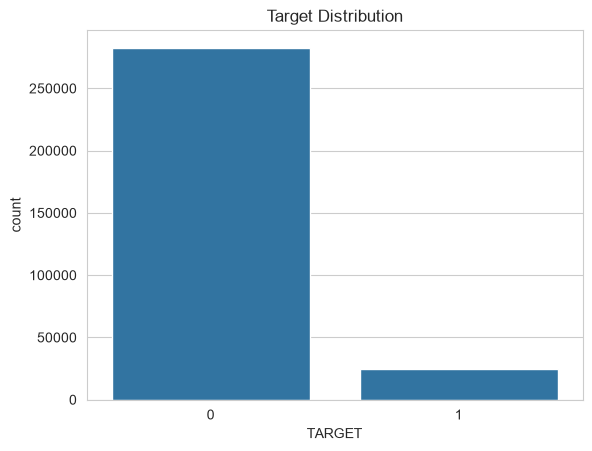

In [20]:
sns.countplot(
    x='TARGET',
    data=application
)

plt.title("Target Distribution")
plt.show()

### Class Imbalance Insight
- Status: Heavily Imbalanced.

- The Split: 92% Class 0 vs. 8% Class 1.

- The Ratio: For every 1 minority case, you have 11.4 majority cases.

In [21]:
## 8. Missing Value Analysis
def missing_values(df):
    
    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": (
            df.isnull().sum() / len(df)
        ) * 100
    })

    return (
        missing
        .sort_values(
            "Missing %",
            ascending=False
        )
    )

In [22]:
missing_values(application).head(20)

,Missing Count,Missing %
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


### Performed Tasks List
```text
Business Understanding

Load all datasets

Dataset Inventory

Relationship Mapping

Data Audit Function

Target Analysis

Missing Value Analysis

```